# 6×8: el moment en què surt, i si abans ha sortit 6×7

**Part 1 — el moment.** L'encert de 6×8 canvia segons quan apareix dins del test? Dues
variables per intent: la **posició** (1a, 2a, 3a… operació del pack) i els **segons
transcorreguts** des de l'inici del pack.

**Part 2 — 6×7 abans.** Per a cada intent de 6×8, si **6×7 ja havia sortit abans en aquella
mateixa sessió**, i què passa amb l'encert i amb el temps de resposta de les correctes.

Tot són recomptes i mitjanes observades, amb la n i l'interval de confiança a la vista.

## Què és cada element de les figures

| element | què és |
|---|---|
| **punt** | el valor observat del grup: encert = `k / n`; RT = mitjana geomètrica dels segons |
| **barra vertical** | interval de confiança del 95 % (Wilson per a proporcions, t de Student sobre log(RT) per als temps) |
| **barra grisa de fons** | la **n** del punt, a l'**eix dret** |
| **línia puntejada grisa** | l'encert del **mateix alumne a la resta d'aquella sessió**. Si baixa alhora que la corba de 6×8, el que canvia amb la posició és *qui* hi ha, no com respon a 6×8 |

**Dades:** ES_2025, edats 8-15, test A998. `queries/a998_position_effect_6x8.sql` (un
registre per intent de 6×8) i `queries/a998_prime_6x7_before_6x8.sql` (el mateix, amb si 6×7
havia sortit abans). Les capçaleres dels `.sql` documenten cada decisió.


In [1]:
# --- boilerplate + parametres -------------------------------------------------
import sys
from pathlib import Path

HERE = Path.cwd()                      # descriptive/
ROOT = HERE
while ROOT != ROOT.parent and not (ROOT / "databricks_connector.py").exists():
    ROOT = ROOT.parent
assert (ROOT / "databricks_connector.py").exists(), "no trobo databricks_connector.py pujant des de HERE"
sys.path.insert(0, str(ROOT))

from cached_query import cached_query   # SEMPRE despres de sys.path.insert

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st

QUERY_DIR = HERE / "queries"
CACHE_DIR = HERE / "cache"
PLOT_DIR  = HERE / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

YEARS = ["ES_2025"]         # Decisio #8
AGES  = list(range(8, 16))  # 8..15, Decisio #2
MIN_BIN_N = 250             # mostra minima per punt de les corbes
MIN_GROUP_N = 25            # grups mes petits no es dibuixen (es diu quins cauen)
WINDOW_K = 5                # finestra simetrica del placebo: K items abans i K despres
RT_MIN, RT_MAX = 0.2, 60.0  # retall de RT: sota 0,2 s no hi ha lectura possible;
                            # per damunt de 60 s, dins d'un pack de 120 s, es una distraccio
PLOTS_SAVE = True

def run_sql(name, years=YEARS):
    """Llegeix el .sql, substitueix el marcador -- {YEARS} i el passa a cached_query."""
    path = QUERY_DIR / name
    years_sql = ", ".join(f"'{y}'" for y in years)
    text = path.read_text(encoding="utf-8").replace(
        "AND s.academic_year_id IN ('ES_2025')   -- {YEARS}",
        f"AND s.academic_year_id IN ({years_sql})   -- {{YEARS}}")
    assert years_sql in text, f"la substitucio del marcador -- {{YEARS}} ha fallat a {name}"
    return cached_query(path, CACHE_DIR, sql_text=text)

print("HERE:", HERE, "| ROOT:", ROOT, "| YEARS:", YEARS)


HERE: c:\Users\maria.garcia\Desktop\MULTIPLY\descriptive | ROOT: c:\Users\maria.garcia\Desktop\MULTIPLY | YEARS: ['ES_2025']


In [2]:
# --- utilitats: intervals de confianca i bins --------------------------------
def wilson(k, n, z=1.959963984540054):
    """IC del 95% de Wilson per a una proporcio: no se surt de [0,1] i aguanta n petita."""
    k = np.asarray(k, dtype=float); n = np.asarray(n, dtype=float)
    p = np.where(n > 0, k / n, np.nan)
    den = 1 + z**2 / n
    cen = (p + z**2 / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    # amb k = 0 o k = n els dos limits valen p; la coma flotant pot donar hi < p per
    # 1e-16 i matplotlib peta amb "yerr must not contain negative values"
    return p, np.clip(np.minimum(cen - half, p), 0, 1), np.clip(np.maximum(cen + half, p), 0, 1)


def adaptive_bins(d, col, min_n, fine_edges):
    """Bins fins fusionats d'esquerra a dreta fins que cada bin arriba a min_n.

    Amb amplada fixa, el darrer punt de la cua (posicions o temps alts) seria soroll;
    fusionant, cada punt te la seva n garantida. L'ultim bin, si es queda curt, es
    fusiona cap enrere.
    """
    idx = np.digitize(d[col].to_numpy(), fine_edges, right=False)
    groups, cur = [], []
    for b in range(1, len(fine_edges)):
        cur.append(b)
        if np.isin(idx, cur).sum() >= min_n:
            groups.append(cur); cur = []
    if cur:
        if groups: groups[-1] = groups[-1] + cur
        else:      groups.append(cur)

    rows = []
    for g in groups:
        sub = d[np.isin(idx, g)]
        if len(sub) == 0:
            continue
        rows.append(dict(v_min=sub[col].min(), v_max=sub[col].max(), center=sub[col].mean(),
                         n=len(sub), k=int(sub.is_correct.sum()),
                         baseline=float(np.average(sub.baseline, weights=sub.n_other))))
    out = pd.DataFrame(rows)
    assert out.n.sum() == len(d), "algun valor ha caigut fora de fine_edges"
    out["p"], out["lo_ci"], out["hi_ci"] = wilson(out.k, out.n)
    return out


def geo_mean_ci(x):
    """Mitjana geometrica i IC 95% d'un vector de temps (t de Student sobre log)."""
    y = np.log(np.asarray(x, float))
    if len(y) < 2:          # amb un sol valor no hi ha interval, i np.std(ddof=1) avisa
        return np.exp(y.mean()), np.nan, np.nan
    m, se = y.mean(), y.std(ddof=1) / np.sqrt(len(y))
    t = st.t.ppf(0.975, len(y) - 1)
    return np.exp(m), np.exp(m - t * se), np.exp(m + t * se)


# Les vores fines han de cobrir sempre el maxim observat (adaptive_bins ho comprova)
POS_FINE  = np.arange(1, 260)
TIME_FINE = np.arange(0, 302.5, 2.5)


In [3]:
# --- carrega 1/2: un registre per intent de 6x8 -------------------------------
raw = run_sql("a998_position_effect_6x8.sql")
for c in ["racing_sitting", "multi_run_sitting"]:
    raw[c] = raw[c].astype(bool)

def population(df, verbose=True):
    """Filtres de la poblacio d'analisi. Cap filtre es silencios: es diu que cau."""
    d = df.copy()
    steps = [("crua", len(d))]
    d = d[~d.racing_sitting]                         # sessions amb ritme anomal, Decisio #12
    steps.append(("- sessions de ritme anomal", len(d)))
    d = d[~d.multi_run_sitting]                      # pack corregut dues vegades
    steps.append(("- pack corregut 2 cops", len(d)))
    d = d[d.occurrence_no == 1]                      # nomes la primera aparicio de 6x8
    steps.append(("- repeticions de 6x8", len(d)))
    d = d[d.statement_idx >= 1]                      # Decisio #7: el primer item porta el
    steps.append(("- posicio 1", len(d)))            # compte enrere (mediana 11-16 s)
    d = d[d.n_other > 0]
    steps.append(("- sense linia base", len(d)))
    d = d[d.classroom_course_age.isin(AGES)].copy()
    steps.append(("edats 8-15", len(d)))
    d["baseline"] = d.n_other_correct / d.n_other
    if verbose:
        prev = None
        for label, n in steps:
            print(f"  {label:<28} {n:>8,}" + ("" if prev is None else f"  ({n - prev:+,})"))
            prev = n
    return d

print(f"{len(raw):,} intents de 6x8 | {raw.sitting_key.nunique():,} sessions | "
      f"{raw.student_key.nunique():,} alumnes\n")
print("Poblacio d'analisi:")
pop = population(raw)
print(f"\n{len(pop):,} intents | {pop.student_key.nunique():,} alumnes | "
      f"encert global {pop.is_correct.mean():.1%}")

# comprovacions basiques abans de dibuixar res
assert (pop.elapsed_s >= 0).all()
assert (pop.position == pop.statement_idx + 1).all()
assert pop.groupby("sitting_key").classroom_course_age.nunique().max() == 1

print("\nMostra per edat i pack (cada edat te el seu pack: 8 -> 16/20, 9 -> 20/39, 10+ -> 39):")
print(pd.crosstab(pop.classroom_course_age, pop.activity_pack, margins=True))


61,395 intents de 6x8 | 59,393 sessions | 51,839 alumnes

Poblacio d'analisi:
  crua                           61,395
  - sessions de ritme anomal     49,368  (-12,027)
  - pack corregut 2 cops         49,366  (-2)
  - repeticions de 6x8           49,323  (-43)
  - posicio 1                    46,433  (-2,890)
  - sense linia base             46,389  (-44)
  edats 8-15                     46,389  (+0)

46,389 intents | 41,706 alumnes | encert global 61.7%

Mostra per edat i pack (cada edat te el seu pack: 8 -> 16/20, 9 -> 20/39, 10+ -> 39):
activity_pack           16     20     39    All
classroom_course_age                           
8                     7116   3366      0  10482
9                      193  10549   1574  12316
10                      93    180   6356   6629
11                      59    129   7274   7462
12                       0      0   3496   3496
13                       0      1   3655   3656
14                       0      0   1812   1812
15                   

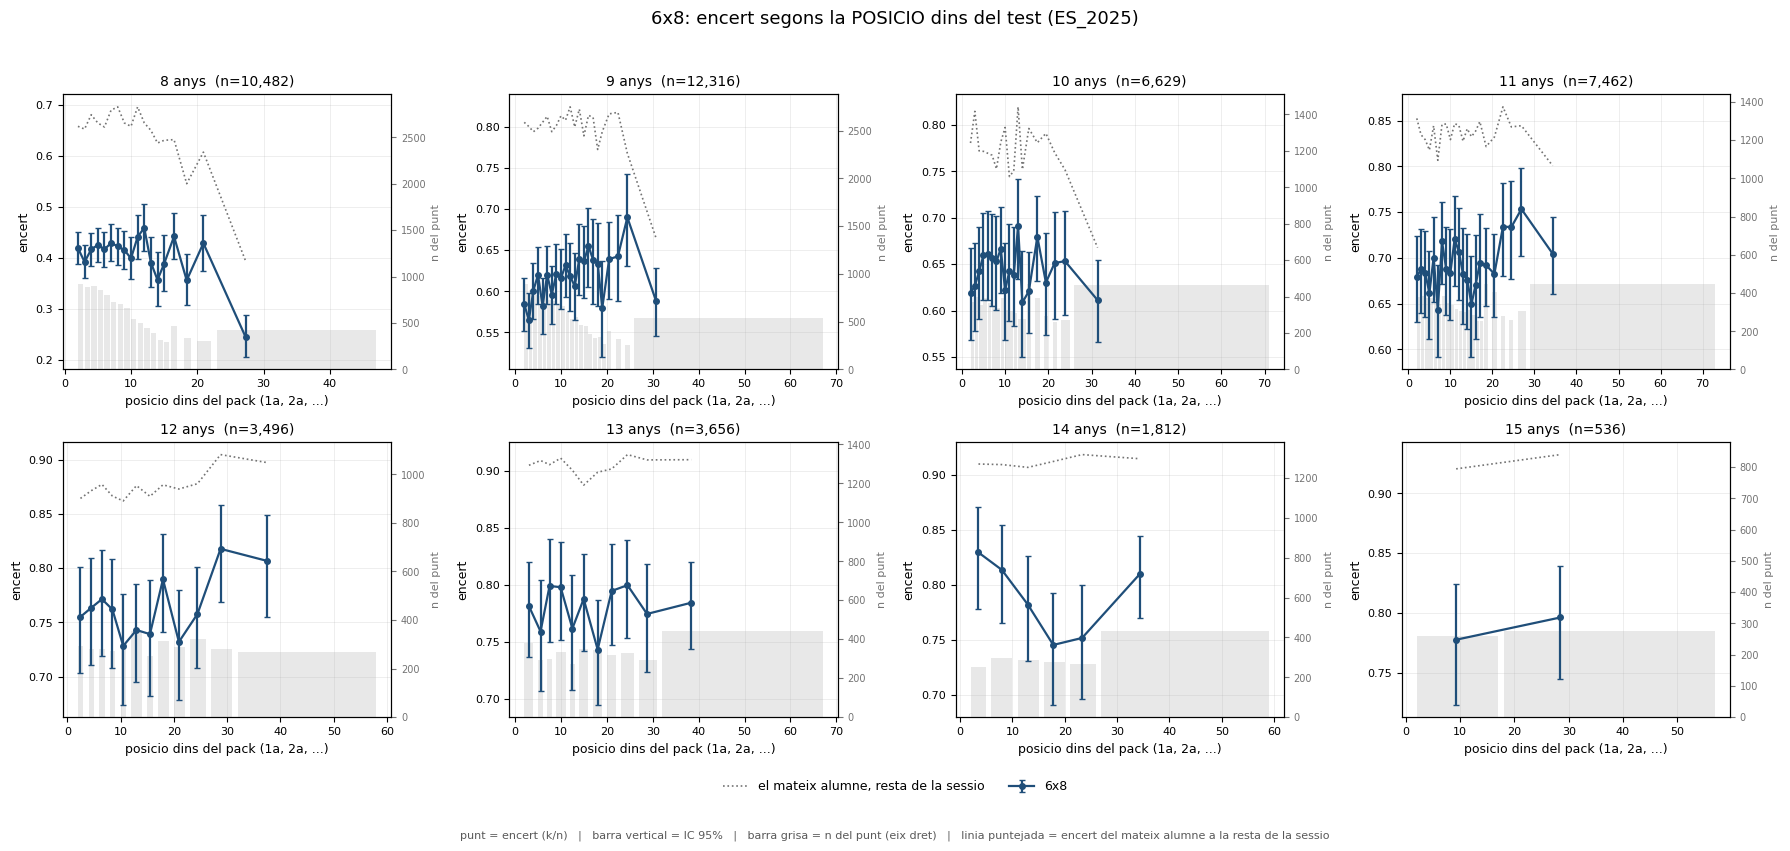

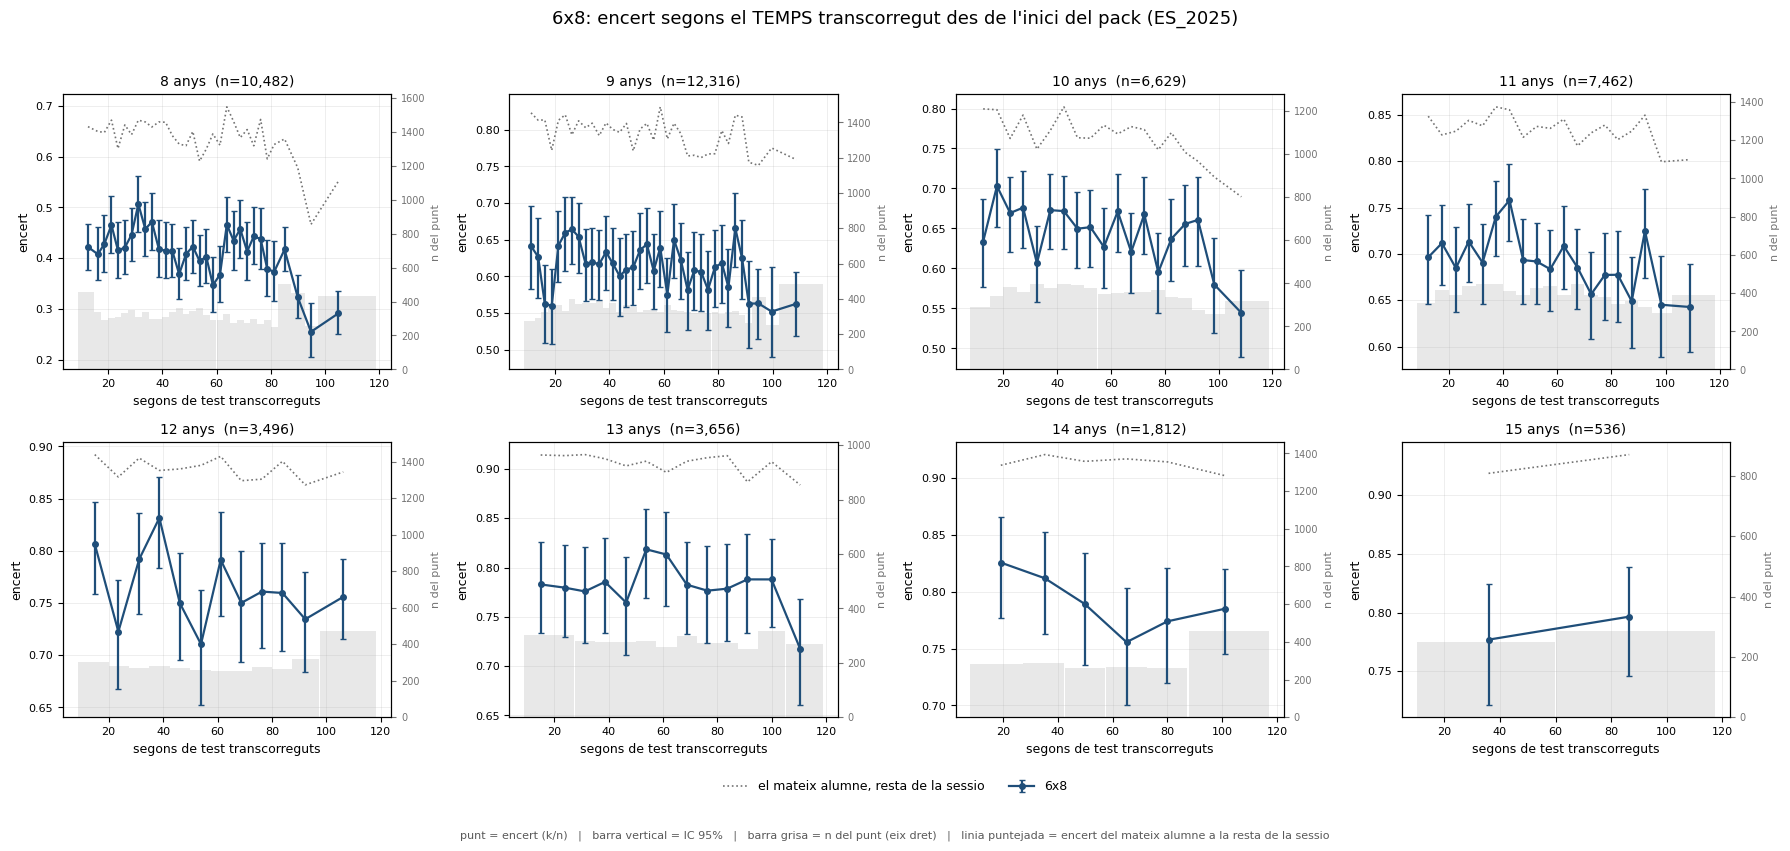

In [4]:
# --- FIGURES 1 i 2: encert de 6x8 per posicio i per temps ---------------------
FIG_NOTE = ("punt = encert (k/n)   |   barra vertical = IC 95%   |   barra grisa = n del punt "
            "(eix dret)   |   linia puntejada = encert del mateix alumne a la resta de la sessio")

def by_age_figure(d, col, fine, xlabel, suptitle, fname):
    fig, axes = plt.subplots(2, 4, figsize=(18, 8.5))
    tables, legend_ax = {}, None
    for ax, age in zip(axes.ravel(), AGES):
        sub = d[d.classroom_course_age == age]
        if len(sub) < MIN_BIN_N:
            ax.set_axis_off(); ax.set_title(f"{age} anys - nomes {len(sub):,} intents", fontsize=9)
            continue
        tab = adaptive_bins(sub, col, MIN_BIN_N, fine)
        tables[age] = tab

        axn = ax.twinx()
        axn.bar(tab.v_min, tab.n, width=np.maximum((tab.v_max - tab.v_min).to_numpy(), 0.8),
                align="edge", color="0.75", alpha=0.35, zorder=1)
        axn.set_ylabel("n del punt", color="0.45", fontsize=8)
        axn.tick_params(axis="y", colors="0.45", labelsize=7)
        axn.set_ylim(0, tab.n.max() * 3.2)     # les barres es queden a la franja baixa
        ax.set_zorder(axn.get_zorder() + 1); ax.patch.set_visible(False)

        ax.plot(tab.center, tab.baseline, color="0.45", lw=1.2, ls=":", zorder=2,
                label="el mateix alumne, resta de la sessio")
        ax.errorbar(tab.center, tab.p, yerr=[tab.p - tab.lo_ci, tab.hi_ci - tab.p],
                    fmt="o-", ms=4, lw=1.6, capsize=2.5, color="#1f4e79", zorder=3, label="6x8")
        ax.set_title(f"{age} anys  (n={len(sub):,})", fontsize=10)
        ax.set_xlabel(xlabel, fontsize=9); ax.set_ylabel("encert", fontsize=9)
        ax.tick_params(labelsize=8); ax.grid(alpha=0.25, lw=0.6)
        legend_ax = ax
    if legend_ax is not None:
        h, l = legend_ax.get_legend_handles_labels()
        fig.legend(h, l, loc="lower center", ncol=2, frameon=False, fontsize=9,
                   bbox_to_anchor=(0.5, 0.045))
    fig.suptitle(suptitle, fontsize=13)
    fig.text(0.5, 0.005, FIG_NOTE, ha="center", fontsize=8, color="0.35")
    fig.tight_layout(rect=[0, 0.085, 1, 0.96])
    if PLOTS_SAVE:
        for ext in ("png", "pdf"):
            fig.savefig(PLOT_DIR / f"{fname}.{ext}", dpi=150, bbox_inches="tight")
    plt.show()
    return tables

pos_tables = by_age_figure(
    pop, "position", POS_FINE, "posicio dins del pack (1a, 2a, ...)",
    "6x8: encert segons la POSICIO dins del test (ES_2025)",
    "a998_6x8_accuracy_by_position")

time_tables = by_age_figure(
    pop, "elapsed_s", TIME_FINE, "segons de test transcorreguts",
    "6x8: encert segons el TEMPS transcorregut des de l'inici del pack (ES_2025)",
    "a998_6x8_accuracy_by_elapsed_time")


In [5]:
# --- les taules que hi ha darrere de les dues figures -------------------------
def print_tables(tables, unit):
    for age, tab in tables.items():
        t = tab.copy()
        t["bin"] = (t.v_min.round(0).astype(int).astype(str) + "-" +
                    t.v_max.round(0).astype(int).astype(str) + unit)
        t["diff_vs_base"] = t.p - t.baseline
        print(f"\n--- {age} anys")
        print(t[["bin", "n", "k", "p", "lo_ci", "hi_ci", "baseline", "diff_vs_base"]]
              .round(3).to_string(index=False))

print("=== POSICIO ===");  print_tables(pos_tables, "")
print("\n\n=== TEMPS ==="); print_tables(time_tables, "s")


=== POSICIO ===

--- 8 anys
  bin   n   k     p  lo_ci  hi_ci  baseline  diff_vs_base
  2-2 926 388 0.419  0.388  0.451     0.657        -0.238
  3-3 883 346 0.392  0.360  0.424     0.652        -0.260
  4-4 903 376 0.416  0.385  0.449     0.680        -0.264
  5-5 856 364 0.425  0.393  0.459     0.664        -0.239
  6-6 797 332 0.417  0.383  0.451     0.656        -0.240
  7-7 727 312 0.429  0.394  0.465     0.689        -0.260
  8-8 708 299 0.422  0.386  0.459     0.696        -0.273
  9-9 660 274 0.415  0.378  0.453     0.664        -0.249
10-10 539 215 0.399  0.358  0.441     0.657        -0.259
11-11 499 220 0.441  0.398  0.485     0.696        -0.255
12-12 447 205 0.459  0.413  0.505     0.664        -0.206
13-13 389 152 0.391  0.344  0.440     0.650        -0.259
14-14 314 112 0.357  0.306  0.411     0.625        -0.268
15-15 296 115 0.389  0.335  0.445     0.630        -0.242
16-17 464 205 0.442  0.397  0.487     0.631        -0.190
18-19 340 121 0.356  0.307  0.408     0.545 

---

# Part 2 — Havia sortit 6×7 abans?

Per a cada intent de 6×8, es mira si **6×7 ja havia aparegut abans en aquella mateixa
sessió**, i es comparen dos grups: **6×7 vist abans** i **6×7 no vist abans**. Dues coses:

1. **l'encert** de 6×8,
2. el **temps de resposta de les correctes** (mitjana geomètrica, perquè els temps són
   asimètrics i una mitjana normal la dominarien les respostes molt llargues).

**Dues coses a tenir al cap quan mires les figures:**

- **El pack 16 no conté 6×7** (el seu conjunt és {a×2, a×4, a×5, a×8}). Allà l'exposició és
  impossible, així que queda fora — i **l'edat 8 perd ~2/3 de la seva mostra**, perquè es
  queda només amb el pack 20.
- **Compara sempre dins de la mateixa franja de posició** (la columna dreta de cada figura).
  Com més avançada la posició, més probable és haver vist 6×7 (del 2 % a les primeres
  posicions al 20 % a partir de la 31a), així que la comparació global de dalt de tot barreja
  posicions i no és llegible per si sola.


In [6]:
# --- carrega 2/2: exposicio previa a 6x7 --------------------------------------
prime = run_sql("a998_prime_6x7_before_6x8.sql")
for c in ["racing_sitting", "multi_run_sitting"]:
    prime[c] = prime[c].astype(bool)

# Tres grups. El color diu com li va anar el 6x7 PREVI, no si l'ha vist:
#   blau  = no l'havia vist
#   verd  = l'havia vist i el va encertar
#   vermell = l'havia vist i el va fallar
# `prev_6x7_correct` es refereix a l'ULTIMA aparicio de 6x7 abans d'aquest 6x8
# (si n'hi va haver mes d'una, compta la mes propera).
GROUPS = [("no vist",       "6x7 NO vist abans",          "#1f4e79"),
          ("vist, encertat", "6x7 vist i ENCERTAT",       "#2e7d32"),
          ("vist, fallat",   "6x7 vist i FALLAT",         "#b3261e")]
GROUP_ORDER = [g[0] for g in GROUPS]

def add_group(d):
    g = np.where(d.seen_6x7_before == 0, "no vist",
        np.where(d.prev_6x7_correct == 1, "vist, encertat", "vist, fallat"))
    d = d.copy()
    d["grup"] = pd.Categorical(g, categories=GROUP_ORDER, ordered=True)
    # si esta exposat, prev_6x7_correct no pot ser desconegut
    assert d.loc[d.seen_6x7_before == 1, "prev_6x7_correct"].notna().all()
    return d

def prime_population(df, verbose=True):
    d = df.copy()
    steps = [("crua", len(d))]
    d = d[d.pack_has_6x7 == 1]                       # el pack 16 no conte 6x7
    steps.append(("- packs sense 6x7 (pack 16)", len(d)))
    d = d[~d.racing_sitting];   steps.append(("- sessions de ritme anomal", len(d)))
    d = d[~d.multi_run_sitting]; steps.append(("- pack corregut 2 cops", len(d)))
    d = d[d.occurrence_no == 1]; steps.append(("- repeticions de 6x8", len(d)))
    d = d[d.statement_idx >= 1]; steps.append(("- posicio 1", len(d)))
    d = d[d.classroom_course_age.isin(AGES)].copy()
    steps.append(("edats 8-15", len(d)))
    d["posbin"] = pd.cut(d.position, [0, 5, 10, 15, 20, 30, np.inf],
                         labels=["01-05", "06-10", "11-15", "16-20", "21-30", "31+"])
    assert d.posbin.notna().all()
    if verbose:
        prev = None
        for label, n in steps:
            print(f"  {label:<30} {n:>8,}" + ("" if prev is None else f"  ({n - prev:+,})"))
            prev = n
    return add_group(d)

# comprovacio: si el pack no conte 6x7, no hi pot haver ningu exposat
assert prime.loc[prime.pack_has_6x7 == 0, "seen_6x7_before"].sum() == 0

print("Quanta mostra perd cada edat en treure el pack 16:")
lost = prime.assign(fora=prime.pack_has_6x7 == 0).groupby("classroom_course_age").fora.agg(
    ["size", "sum"]).rename(columns={"size": "n_total", "sum": "n_fora"})
lost["pct_fora"] = (100 * lost.n_fora / lost.n_total).round(1)
print(lost.to_string())

print("\nPoblacio de la part 2:")
pr = prime_population(prime)
print(f"\n{len(pr):,} intents | {pr.student_key.nunique():,} alumnes")
print("\nGrandaria dels tres grups:")
print(pr.grup.value_counts().reindex(GROUP_ORDER).to_frame("n").assign(
    pct=lambda t: (100 * t.n / len(pr)).round(1)).to_string())

print("\nGrups per edat (compte amb les cel.les petites):")
print(pd.crosstab(pr.classroom_course_age, pr.grup).to_string())
print("\nGrups per franja de posicio:")
print(pd.crosstab(pr.posbin, pr.grup).to_string())


Quanta mostra perd cada edat en treure el pack 16:
                      n_total  n_fora  pct_fora
classroom_course_age                           
8                       17899   12380      69.2
9                       15906     276       1.7
10                       8526     159       1.9
11                       8830      98       1.1
12                       3853       0       0.0
13                       3920       0       0.0
14                       1906       0       0.0
15                        555       0       0.0

Poblacio de la part 2:
  crua                             61,395
  - packs sense 6x7 (pack 16)      48,482  (-12,913)
  - sessions de ritme anomal       41,168  (-7,314)
  - pack corregut 2 cops           41,168  (+0)
  - repeticions de 6x8             41,168  (+0)
  - posicio 1                      38,953  (-2,215)
  edats 8-15                       38,953  (+0)

38,953 intents | 35,217 alumnes

Grandaria dels tres grups:
                    n   pct
grup         

Global (barreja posicions: veure la nota de dalt):
          grup     n     k  encert  lo_ci  hi_ci
       no vist 35665 23697  0.6644 0.6595 0.6693
vist, encertat  2470  1881  0.7615 0.7443 0.7779
  vist, fallat   818   259  0.3166 0.2857 0.3493

Per edat:
 classroom_course_age           grup     n    k  encert  lo_ci  hi_ci
                    8        no vist  3006 1481  0.4927 0.4748 0.5106
                    8 vist, encertat   229  139  0.6070 0.5425 0.6680
                    8   vist, fallat   141   20  0.1418 0.0937 0.2090
                    9        no vist 10702 6549  0.6119 0.6027 0.6211
                    9 vist, encertat  1032  757  0.7335 0.7057 0.7596
                    9   vist, fallat   399  133  0.3333 0.2889 0.3810
                   10        no vist  6220 4018  0.6460 0.6340 0.6578
                   10 vist, encertat   235  190  0.8085 0.7534 0.8537
                   10   vist, fallat    83   23  0.2771 0.1923 0.3816
                   11        no vist  6954

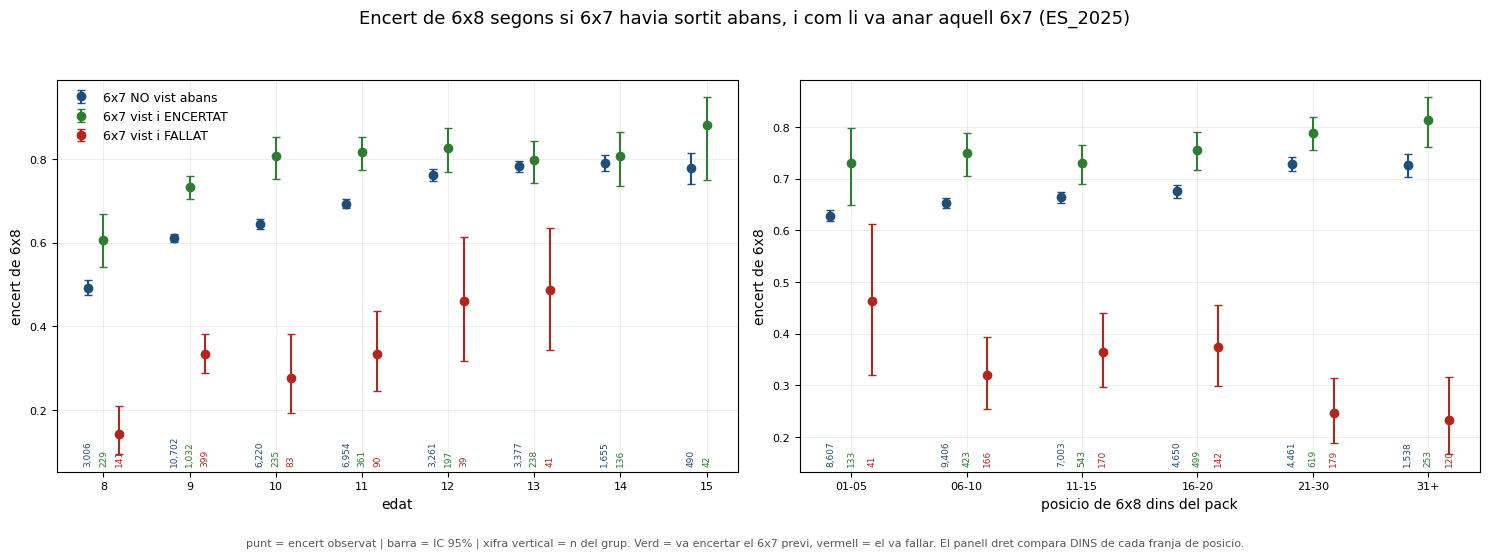

grups amb n < 25 no dibuixats (si, a les taules):
   classroom_course_age=14 / vist, fallat / n=21
   classroom_course_age=15 / vist, fallat / n=4


In [7]:
# --- ENCERT de 6x8 pels tres grups -------------------------------------------
def acc_table(d, by=None):
    keys = ["grup"] if by is None else [by, "grup"]
    g = d.groupby(keys, observed=True).is_correct.agg(["size", "sum"])
    g.columns = ["n", "k"]
    g["encert"], g["lo_ci"], g["hi_ci"] = wilson(g.k, g.n)
    return g.reset_index()

print("Global (barreja posicions: veure la nota de dalt):")
print(acc_table(pr).round(4).to_string(index=False))
for by, label in [("classroom_course_age", "edat"), ("posbin", "franja de posicio")]:
    print(f"\nPer {label}:")
    print(acc_table(pr, by).round(4).to_string(index=False))


def three_group_figure(d, table_fn, value_col, ylabel, suptitle, fname, note):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    hidden = []
    for ax, (by, xlabel) in zip(axes, [("classroom_course_age", "edat"),
                                       ("posbin", "posicio de 6x8 dins del pack")]):
        tab = table_fn(d, by)
        small = tab[tab.n < MIN_GROUP_N]
        hidden += [f"{by}={v} / {g} / n={n}" for v, g, n in zip(small[by], small.grup, small.n)]
        tab = tab[tab.n >= MIN_GROUP_N]
        # ordenar pels valors, no pel text: sorted() sobre strings posa "10" abans de "8"
        # (i per a posbin, sort_values respecta l'ordre de les categories)
        order = list(tab[by].drop_duplicates().sort_values())
        xs = {str(v): i for i, v in enumerate(order)}
        # tres grups: desplacats a esquerra, centre i dreta per no encavalcar-se
        for (gname, glabel, color), off in zip(GROUPS, (-0.18, 0.0, 0.18)):
            t = tab[tab.grup == gname]
            if not len(t):
                continue
            x = np.array([xs[v] for v in t[by].astype(str)]) + off
            ax.errorbar(x, t[value_col],
                        yerr=[t[value_col] - t.lo_ci, t.hi_ci - t[value_col]],
                        fmt="o", ms=6, capsize=3, lw=1.5, color=color, label=glabel)
            for xi, n in zip(x, t.n):
                ax.annotate(f"{n:,}", (xi, 0.02), xycoords=("data", "axes fraction"),
                            ha="center", fontsize=6.5, color=color, rotation=90)
        ax.set_xticks(range(len(order))); ax.set_xticklabels([str(v) for v in order])
        ax.set_xlabel(xlabel, fontsize=10); ax.set_ylabel(ylabel, fontsize=10)
        ax.grid(alpha=0.25, lw=0.6); ax.tick_params(labelsize=8)
    axes[0].legend(fontsize=9, frameon=False)
    fig.suptitle(suptitle, fontsize=13)
    fig.text(0.5, 0.005, note, ha="center", fontsize=8, color="0.35")
    fig.tight_layout(rect=[0, 0.04, 1, 0.94])
    if PLOTS_SAVE:
        for ext in ("png", "pdf"):
            fig.savefig(PLOT_DIR / f"{fname}.{ext}", dpi=150, bbox_inches="tight")
    plt.show()
    if hidden:
        print(f"grups amb n < {MIN_GROUP_N} no dibuixats (si, a les taules):")
        for h in sorted(set(hidden)):
            print("  ", h)

three_group_figure(
    pr, acc_table, "encert", "encert de 6x8",
    "Encert de 6x8 segons si 6x7 havia sortit abans, i com li va anar aquell 6x7 (ES_2025)",
    "a998_prime6x7_accuracy",
    "punt = encert observat | barra = IC 95% | xifra vertical = n del grup. Verd = va encertar "
    "el 6x7 previ, vermell = el va fallar. El panell dret compara DINS de cada franja de posicio.")


25,825 respostes correctes de 6x8 dins del retall [0.2, 60.0] s
                    n
grup                 
no vist         23685
vist, encertat   1881
vist, fallat      259

Global (barreja posicions):
          grup     n  rt_geometric  lo_ci  hi_ci  mediana
       no vist 23685         5.981  5.936  6.026    5.483
vist, encertat  1881         5.260  5.136  5.386    4.893
  vist, fallat   259         6.334  5.934  6.762    5.882

Per edat:
 classroom_course_age           grup    n  rt_geometric  lo_ci  hi_ci  mediana
                    8        no vist 1481         8.027  7.780  8.282    7.600
                    8 vist, encertat  139         7.393  6.727  8.125    7.534
                    8   vist, fallat   20         6.674  5.169  8.617    6.741
                    9        no vist 6544         6.910  6.810  7.012    6.300
                    9 vist, encertat  757         5.701  5.502  5.906    5.433
                    9   vist, fallat  133         6.690  6.102  7.335    6.394
 

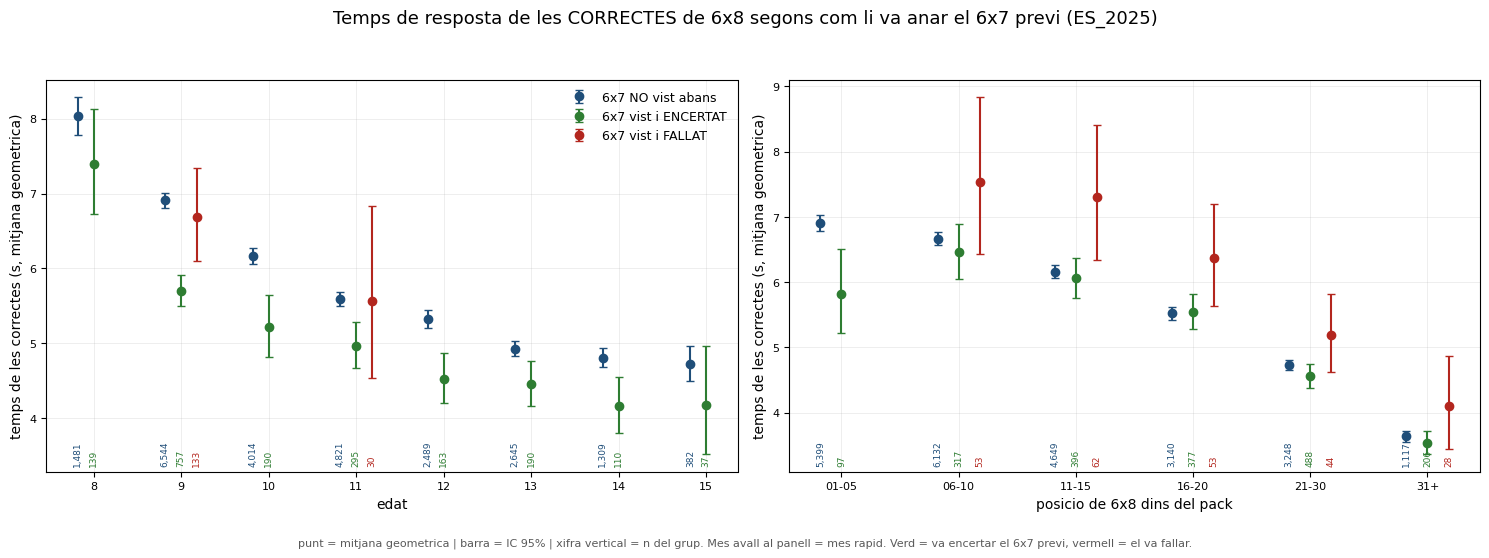

grups amb n < 25 no dibuixats (si, a les taules):
   classroom_course_age=10 / vist, fallat / n=23
   classroom_course_age=12 / vist, fallat / n=18
   classroom_course_age=13 / vist, fallat / n=20
   classroom_course_age=14 / vist, fallat / n=12
   classroom_course_age=15 / vist, fallat / n=3
   classroom_course_age=8 / vist, fallat / n=20
   posbin=01-05 / vist, fallat / n=19


In [8]:
# --- TEMPS DE RESPOSTA de les correctes, pels tres grups ----------------------
rt = pr[(pr.is_correct == 1) & pr.rt_seconds.between(RT_MIN, RT_MAX)].copy()
print(f"{len(rt):,} respostes correctes de 6x8 dins del retall [{RT_MIN}, {RT_MAX}] s")
print(rt.grup.value_counts().reindex(GROUP_ORDER).to_frame("n").to_string())

def rt_table(d, by=None):
    keys = ["grup"] if by is None else [by, "grup"]
    rows = []
    for key, sub in d.groupby(keys, observed=True):
        if not isinstance(key, tuple):
            key = (key,)
        g, lo, hi = geo_mean_ci(sub.rt_seconds)
        rows.append(dict(zip(keys, key), n=len(sub), rt_geometric=g, lo_ci=lo, hi_ci=hi,
                         mediana=sub.rt_seconds.median()))
    return pd.DataFrame(rows)

print("\nGlobal (barreja posicions):")
print(rt_table(rt).round(3).to_string(index=False))
for by, label in [("classroom_course_age", "edat"), ("posbin", "franja de posicio")]:
    print(f"\nPer {label}:")
    print(rt_table(rt, by).round(3).to_string(index=False))

three_group_figure(
    rt, rt_table, "rt_geometric", "temps de les correctes (s, mitjana geometrica)",
    "Temps de resposta de les CORRECTES de 6x8 segons com li va anar el 6x7 previ (ES_2025)",
    "a998_prime6x7_rt_correct",
    "punt = mitjana geometrica | barra = IC 95% | xifra vertical = n del grup. Mes avall al "
    "panell = mes rapid. Verd = va encertar el 6x7 previ, vermell = el va fallar.")


---

## El grup placebo: i els que veuen 6×7 **després**?

L'explicaci&oacute; alternativa al priming &eacute;s aquesta: els alumnes r&agrave;pids fan m&eacute;s &iacute;tems, i per tant
topen m&eacute;s sovint amb el 6&times;7 abans del 6&times;8. Si &eacute;s aix&ograve;, el que veiem no &eacute;s que el 6&times;7
ajudi, sin&oacute; que **ja eren r&agrave;pids**.

Es pot comprovar amb un grup **placebo**: els intents de 6&times;8 en qu&egrave; el 6&times;7 apareix
**despr&eacute;s**, a la mateixa sessi&oacute;. Aquests alumnes s&oacute;n del mateix tipus &mdash; arriben a veure el
6&times;7 &mdash; per&ograve; en el moment del 6&times;8 el 6&times;7 encara no els podia haver activat res.

| color | grup |
|---|---|
| **blau** | cap 6×7 a prop |
| **taronja** | 6×7 **després** (placebo) |
| **violeta** | 6×7 **abans** |

**Com es llegeix:**

- si el **placebo** &eacute;s tan r&agrave;pid com el grup "abans" &rarr; el que mesur&agrave;vem era **selecci&oacute;**
  (alumnes r&agrave;pids), no priming;
- si el placebo s'assembla al grup "cap" i nom&eacute;s el grup "abans" &eacute;s m&eacute;s r&agrave;pid &rarr; compatible
  amb priming.

**La finestra sim&egrave;trica.** Nom&eacute;s entren els intents amb **K = 5 &iacute;tems abans i 5 despr&eacute;s**, i el
6&times;7 ha de caure dins d'aquesta finestra. Aix&iacute; els tres grups han tingut la mateixa
oportunitat estructural de veure el 6&times;7 a banda i banda: sense aix&ograve;, "tenir 6&times;7 despr&eacute;s"
voldria dir nom&eacute;s "la sessi&oacute; ha continuat", que &eacute;s justament el que volem neutralitzar.

**Es mira dins de cada pack.** L'exposici&oacute; a prop &eacute;s ~3 vegades m&eacute;s freq&uuml;ent al pack 20
(72 operacions) que al pack 39 (190), i el pack 20 &eacute;s ~18 % m&eacute;s lent. Barrejant packs, els
dos grups exposats semblen m&eacute;s lents nom&eacute;s per aix&ograve;.


finestra de +-5 items: 20,269 intents de 6x8 (de 38,953 de la part 2)
                           n
grup_p                      
cap 6x7 a prop         18784
6x7 DESPRES (placebo)    758
6x7 ABANS                727

Per que cal mirar-ho dins de cada pack: l'exposicio a prop no es igual de frequent als dos packs
grup_p         cap 6x7 a prop  6x7 DESPRES (placebo)  6x7 ABANS  % exposats
activity_pack                                                              
20                       5157                    440        379        13.7
39                      13627                    318        348         4.7

Longitud mediana de la sessio per grup (ha de ser semblant, la finestra ja hi obliga):
                       mediana
grup_p                        
cap 6x7 a prop            27.0
6x7 DESPRES (placebo)     24.0
6x7 ABANS                 24.0

=== global ===
               grup_p     n  encert  e_lo  e_hi  n_rt    rt  rt_lo  rt_hi
       cap 6x7 a prop 18784   0.696 0.690 0.703 13

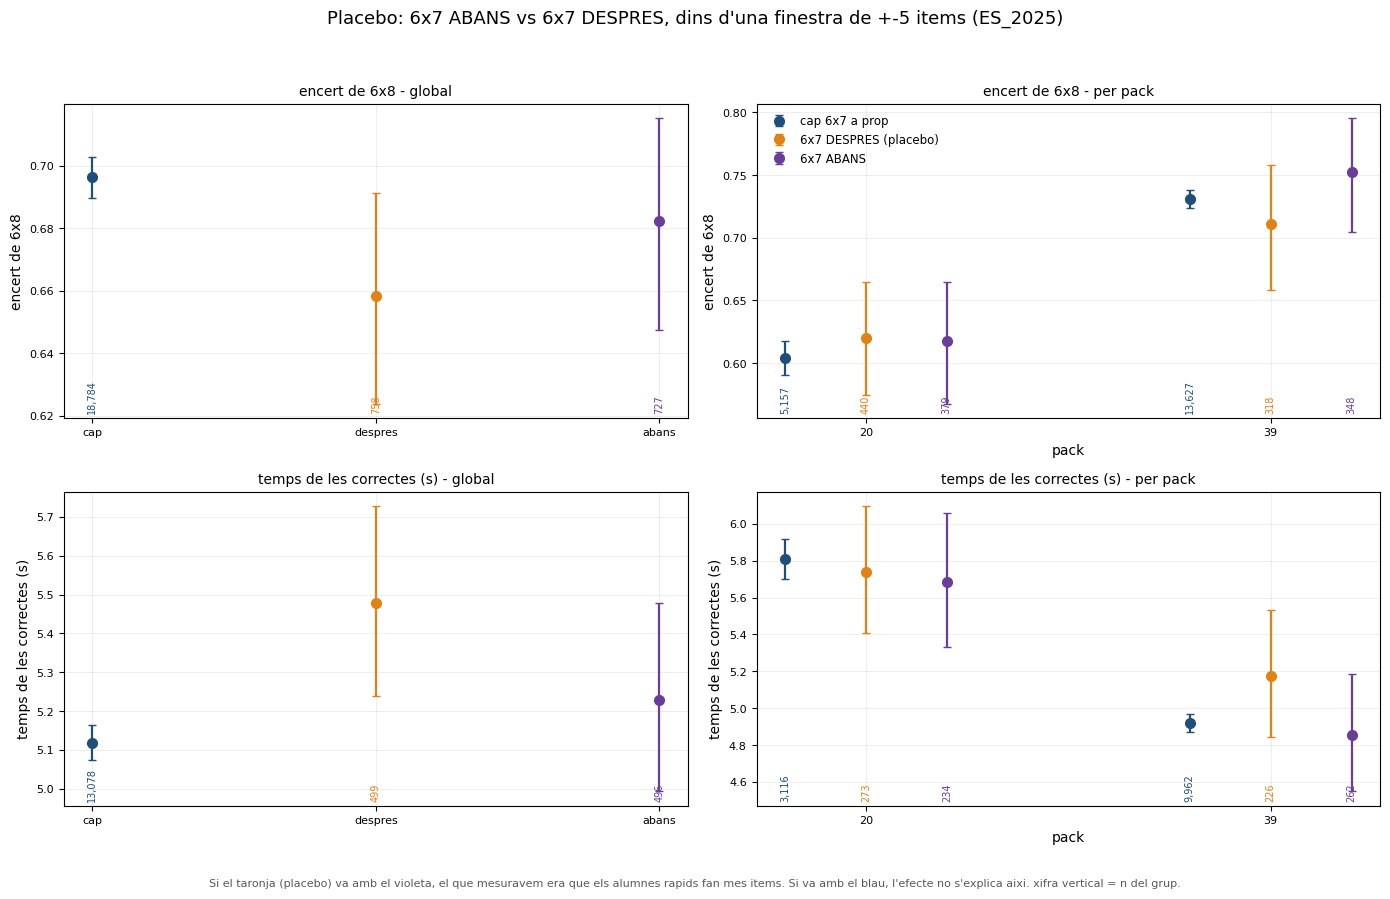

In [9]:
# --- PLACEBO: 6x7 abans vs 6x7 despres, dins d'una finestra simetrica ---------
def add_placebo(d, k=WINDOW_K):
    """Nomes intents amb k items abans i k despres, i el 6x7 dins d'aquesta finestra."""
    items_after = d.sitting_n - 1 - d.statement_idx
    w = d[(d.statement_idx >= k) & (items_after >= k)].copy()
    g = np.where(w.lag_items <= k, "6x7 ABANS",
        np.where(w.lead_items <= k, "6x7 DESPRES (placebo)", "cap 6x7 a prop"))
    w["grup_p"] = pd.Categorical(g, categories=PLACEBO_ORDER, ordered=True)
    return w

PLACEBO = [("cap 6x7 a prop",        "#1f4e79", "cap"),
           ("6x7 DESPRES (placebo)", "#e08214", "despres"),
           ("6x7 ABANS",             "#6a3d9a", "abans")]
PLACEBO_ORDER = [g[0] for g in PLACEBO]

pl = add_placebo(pr)
print(f"finestra de +-{WINDOW_K} items: {len(pl):,} intents de 6x8 "
      f"(de {len(pr):,} de la part 2)")
print(pl.grup_p.value_counts().reindex(PLACEBO_ORDER).to_frame("n").to_string())

print("\nPer que cal mirar-ho dins de cada pack: l'exposicio a prop no es igual de "
      "frequent als dos packs")
comp = pd.crosstab(pl.activity_pack, pl.grup_p)
comp["% exposats"] = (100 * (comp.iloc[:, 1] + comp.iloc[:, 2]) / comp.sum(axis=1)).round(1)
print(comp.to_string())
print("\nLongitud mediana de la sessio per grup (ha de ser semblant, la finestra ja hi obliga):")
print(pl.groupby("grup_p", observed=True).sitting_n.median().to_frame("mediana").to_string())


def placebo_tables(d):
    """Encert i RT de les correctes, pels tres grups: global i per pack."""
    out = {}
    for label, keys in [("global", ["grup_p"]), ("per pack", ["activity_pack", "grup_p"])]:
        rows = []
        for key, sub in d.groupby(keys, observed=True):
            key = key if isinstance(key, tuple) else (key,)
            # wilson() torna arrays de 0 dimensions; sense float() la columna queda
            # de tipus object i el .round(3) de la taula no s'aplica
            p, lo, hi = (float(v) for v in wilson(sub.is_correct.sum(), len(sub)))
            r = sub[sub.rt_seconds.between(RT_MIN, RT_MAX) & (sub.is_correct == 1)]
            g, glo, ghi = geo_mean_ci(r.rt_seconds) if len(r) >= 2 else (np.nan,) * 3
            rows.append(dict(zip(keys, key), n=len(sub), encert=p, e_lo=lo, e_hi=hi,
                             n_rt=len(r), rt=g, rt_lo=glo, rt_hi=ghi))
        out[label] = pd.DataFrame(rows)
    return out

tabs = placebo_tables(pl)
for label, t in tabs.items():
    print(f"\n=== {label} ===")
    print(t.round(3).to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for row, (val, lo, hi, ylabel) in enumerate([
        ("encert", "e_lo", "e_hi", "encert de 6x8"),
        ("rt", "rt_lo", "rt_hi", "temps de les correctes (s)")]):
    for col, (label, by) in enumerate([("global", None), ("per pack", "activity_pack")]):
        ax = axes[row, col]
        t = tabs[label]
        ncol = "n" if val == "encert" else "n_rt"
        t = t[t[ncol] >= MIN_GROUP_N]
        # al panell global cada grup te la seva posicio (i el seu nom a l'eix); al de
        # pack, les posicions son els packs i els grups es desplacen a dins
        xlabels = ([short for _, _, short in PLACEBO] if by is None
                   else [str(v) for v in sorted(t[by].unique())])
        for gi, ((gname, color, short), off) in enumerate(zip(PLACEBO, (-0.2, 0.0, 0.2))):
            sub = t[t.grup_p == gname]
            if not len(sub):
                continue
            x = (np.full(len(sub), float(gi)) if by is None else
                 np.array([xlabels.index(str(v)) for v in sub[by]], dtype=float) + off)
            ax.errorbar(x, sub[val], yerr=[sub[val] - sub[lo], sub[hi] - sub[val]],
                        fmt="o", ms=7, capsize=3, lw=1.6, color=color, label=gname)
            for xi, n in zip(x, sub[ncol]):
                ax.annotate(f"{n:,}", (xi, 0.02), xycoords=("data", "axes fraction"),
                            ha="center", fontsize=7, color=color, rotation=90)
        ax.set_xticks(range(len(xlabels))); ax.set_xticklabels(xlabels)
        ax.set_xlabel("" if by is None else "pack", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(f"{ylabel} - {label}", fontsize=10)
        ax.grid(alpha=0.25, lw=0.6); ax.tick_params(labelsize=8)
axes[0, 1].legend(fontsize=8.5, frameon=False)
fig.suptitle(f"Placebo: 6x7 ABANS vs 6x7 DESPRES, dins d'una finestra de +-{WINDOW_K} items "
             "(ES_2025)", fontsize=13)
fig.text(0.5, 0.005, "Si el taronja (placebo) va amb el violeta, el que mesuravem era que els "
         "alumnes rapids fan mes items. Si va amb el blau, l'efecte no s'explica aixi. "
         "xifra vertical = n del grup.", ha="center", fontsize=8, color="0.35")
fig.tight_layout(rect=[0, 0.035, 1, 0.95])
if PLOTS_SAVE:
    for ext in ("png", "pdf"):
        fig.savefig(PLOT_DIR / f"a998_prime6x7_placebo.{ext}", dpi=150, bbox_inches="tight")
plt.show()


## Com llegir-ho

- **Compara dins de la mateixa franja de posició** (el panell dret de les dues figures de la
  part 2). La comparació global barreja posicions, i haver vist 6×7 abans és molt més
  probable a les posicions tardanes.
- **Els temps es llegeixen en proporció, no en segons.** Un nen de 8 anys parteix de ~8 s i un
  de 14 de ~4,8 s, així que mig segon no vol dir el mateix als dos extrems.
- **Edat 8 va amb compte:** en treure el pack 16 (no conté 6×7) es queda amb ~1/3 de la mostra.
- **Cada edat fa el seu pack** (8 → 16/20, 9 → 20/39, 10+ → 39), així que les comparacions
  entre edats no són comparacions del mateix test.
- **La comparació del placebo va per pack, no barrejada.** A la finestra de ±5, l'exposició a
  prop és ~3 vegades més freqüent al pack 20 que al pack 39, i el pack 20 és ~18 % més lent:
  barrejats, els dos grups exposats semblen més lents només per composició.
- **La finestra deixa poca mostra**: ~350-450 intents per grup exposat. Amb aquesta n, les
  diferències per sota d'un ~8 % de temps no es distingeixen del soroll, i les tres barres se
  solapen. El placebo diu si el senyal gros era selecció; no serveix per mesurar un efecte petit.
- **El verd i el vermell no són grups equivalents**: qui encerta el 6×7 previ és, de mitjana,
  un alumne més fluix o més fort que qui el falla, i aquesta diferència ja hi era abans de
  veure el 6×8. La distància verd-vermell barreja "com li ha anat el fact previ" amb "qui és
  l'alumne"; el que sí que és comparable és cada color contra el blau **dins de la mateixa
  franja de posició**.
- **La meitat dels errors de 6×8 són un sol dígit** (la primera tecla, rebutjada abans
  d'acabar el número). Compten com a error, com a tot el repositori.
